# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 23
## Yoğun Getirme Motoru (Dense Retrieval: Bi-Encoder & Cross-Encoder Mimarisi)

> **Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 4: Retrieval & Hibrit Arama (Day 22–28)  
> **Konu:** Day 23: Cümle Gömmeleri (Sentence Transformers / BERT), Anlamsal Metin Vektörleştirme, Qdrant Vektör Veritabanı ve İki Aşamalı Cross-Encoder Re-Ranking Mimarisi  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.
> **Lisans Badge:** ![License: All Rights Reserved](https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square)

### 1. Endüstriyel Problem ve Motivasyon

Gaziantep 4. OSB Merinos fabrikalarında tezgâh operatörleri ve saha teknisyenleri, karşılaştıkları arızaları kılavuzlardaki standart arıza kodları yerine serbest metinli doğal dille raporlar (örn: *"çözgü ipleri çok gevşek levent durmuyor"* veya *"jakar kafası desenleri birbirine karıştırdı"*).

- **Leksikal Arama Yetersizliği:** Day 22'de geliştirilen Okapi BM25 motoru, teknik terimler ve kodlar birebir eşleştiğinde kusursuz çalışırken; eş anlamlı ifadeler ve muğlak operatör bildirimlerinde semantik benzerliği yakalayamaz.
- **Bi-Encoder (1. Aşama):** `all-MiniLM-L6-v2` modeli dokümanları 384 boyutlu anlamsal vektör uzayına eşler ve **Qdrant Vektör Veritabanı** üzerinde kosinüs benzerliği ile milisaniyeler içinde Top-10 aday getirir.
- **Cross-Encoder Re-Ranker (2. Aşama):** `cross-encoder/ms-marco-TinyBERT-L-2-v2` modeli (Sorgu, Doküman) çiftini tam çapraz dikkat katmanında işleyerek derin alaka skoru hesaplar ve en doğru 3 dokümanı en başa yerleştirir.

### 2. Matematiksel Çerçeve

#### A. Bi-Encoder & Kosinüs Benzerliği
$$\mathbf{u} = \text{BiEncoder}(q) \in \mathbb{R}^{384}, \quad \mathbf{v} = \text{BiEncoder}(d) \in \mathbb{R}^{384}$$
$$\text{Sim}(q, d) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}$$

#### B. Cross-Encoder Çapraz Dikkat & Sigmoid Kalibrasyonu
$$\mathbf{x} = [\text{CLS}] \circ q \circ [\text{SEP}] \circ d \circ [\text{SEP}]$$
$$\text{Score}_{\text{CE}}(q, d) = \sigma(z) = \frac{1}{1 + e^{-z}} \in [0, 1]$$

In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY23_DIR = PROJECT_ROOT / "day23"
DAY_DIR = DAY23_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# 3. Ortam Kurulumu ve Modüllerin Yüklenmesi
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from day23.mini_project.src.models import RawDocument
from day23.mini_project.src.bi_encoder import BiEncoderDenseRetriever
from day23.mini_project.src.vector_store import QdrantVectorStore
from day23.mini_project.src.cross_encoder_reranker import CrossEncoderReranker
from day23.mini_project.src.pipeline import TwoStageRetrievalPipeline
from day23.mini_project.src.evaluator import DenseRetrievalEvaluator

print("✅ Day 23 modülleri başarıyla yüklendi.")

W0924 00:07:04.568000 3084 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


✅ Day 23 modülleri başarıyla yüklendi.


In [2]:
# 4. Merinos Teknik Külliyatının Yüklenmesi
corpus_path = Path("mini_project/fixtures/merinos_technical_corpus.json")
with open(corpus_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

documents = [RawDocument(**doc) for doc in raw_data]
print(f"Külliyattaki toplam teknik doküman sayısı: {len(documents)}")

df_docs = pd.DataFrame([{
    "ID": d.doc_id,
    "Başlık": d.title,
    "Kategori": d.category,
    "Kelime Sayısı": len(d.content.split())
} for d in documents[:5]])
display(df_docs)

Külliyattaki toplam teknik doküman sayısı: 52


,ID,Başlık,Kategori,Kelime Sayısı
0,DOC-001,Van de Wiele Jakarlı Dokuma Tezgâhı Çözgü Geri...,DOKUMA_TEZGAHI_BAKIM,66
1,DOC-002,Dokuma Tezgâhı Ana Tahrik Motoru ve Rulman Yağ...,DOKUMA_TEZGAHI_BAKIM,56
2,DOC-003,Atkı İpliği Akümülatör ve Besleyici Gerilim Ka...,DOKUMA_TEZGAHI_BAKIM,53
3,DOC-004,Ağızlık Açma Mekanizması ve Çerçeve Yükseklik ...,DOKUMA_TEZGAHI_BAKIM,48
4,DOC-005,Pnömatik Rapiyer ve Kıskaç Aşınma Denetim Kıla...,DOKUMA_TEZGAHI_BAKIM,50


In [3]:
# 5. Bi-Encoder Vektörleştirme ve Qdrant İndekslemesi
bi_encoder = BiEncoderDenseRetriever(model_name="all-MiniLM-L6-v2")
cross_encoder = CrossEncoderReranker(model_name="cross-encoder/ms-marco-TinyBERT-L-2-v2")
qdrant_store = QdrantVectorStore(in_memory=True)

pipeline = TwoStageRetrievalPipeline(bi_encoder=bi_encoder, reranker=cross_encoder, vector_store=qdrant_store)
pipeline.index_corpus(documents)

print(f"✅ {len(documents)} doküman Qdrant vektör veritabanına indekslendi.")
print(f"Vektör Boyutu: {bi_encoder.embedding_dim}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

✅ 52 doküman Qdrant vektör veritabanına indekslendi.
Vektör Boyutu: 384


In [4]:
# 6. Qdrant Üzerinde Semantik Arama ve Kategori Filtreleme
ornek_sorgu = "çözgü gerilim levent fren hidrolik basıncı arızası"
print(f"🔎 Test Sorgusu: '{ornek_sorgu}'\n")

# 1. Aşama Bi-Encoder / Qdrant Arama Sonuçları (Top-5)
dense_results = pipeline.search_first_stage(ornek_sorgu, top_k=5, use_qdrant=True)
print("🏆 Bi-Encoder / Qdrant İlk Aşama Sonuçları:")
for r in dense_results:
    print(f"  [{r.rank}] {r.doc_id} | Skor: {r.score:.4f} | Kategori: {r.category} | {r.title}")
    print(f"      Özet: {r.snippet}\n")

🔎 Test Sorgusu: 'çözgü gerilim levent fren hidrolik basıncı arızası'

🏆 Bi-Encoder / Qdrant İlk Aşama Sonuçları:
  [1] DOC-050 | Skor: 0.6945 | Kategori: KALITE_GUVENCE_VE_HATA_TRIAJ | Halı Paketleme, Rulo Sarım Gerginliği ve Nem Koruma Standartları
      Özet: Kalite kontrol masasından onay alan 1. kalite halılar otomatik sarım makinesinde 45 N gerginlikle rulo yapılır. Polietilen shrink ambalaj kaynak sıcaklığı 165°C...

  [2] DOC-040 | Skor: 0.6694 | Kategori: DESEN_VE_JAKAR_YONETIMI | Sırt İpliği (Jüt ve Pamuk) Bağlantı Örgü Yapısı Seçimi
      Özet: Halı zemin iskeletini oluşturan jüt ve pamuk çözgülerin 1/1 bezayağı veya 2/2 dimi örgü bağlantı parametreleri jakar yazılımında tanımlanır. Dimi örgüde sırt do...

  [3] DOC-038 | Skor: 0.6549 | Kategori: DESEN_VE_JAKAR_YONETIMI | Düşük Havlı ve Rölyefli Halılarda Doku İğneleme Parametreleri
      Özet: Rölyef efektli modern halılarda hav yüksekliği 7 mm ile 13 mm arasında kademelendirilir. Düşük hav bölgelerinde jakar platin vuruş gü

In [5]:
# 7. Cross-Encoder ile İki Aşamalı Re-ranking (Yeniden Sıralama)
reranked_results, bi_time, ce_time = pipeline.search_and_rerank(
    query=ornek_sorgu,
    first_stage_top_k=10,
    final_top_k=3,
    use_qdrant=True
)

print(f"⏱️ Gecikmeler: Bi-Encoder: {bi_time:.2f} ms | Cross-Encoder: {ce_time:.2f} ms | Toplam: {bi_time+ce_time:.2f} ms\n")
print("🎯 Cross-Encoder Re-ranked Sonuçları:")
for r in reranked_results:
    print(f"  [{r.rank}] {r.doc_id} | CE Skoru: {r.cross_encoder_score:.4f} (Bi-Enc: {r.bi_encoder_score:.4f}) | {r.title}")
    print(f"      Özet: {r.snippet}\n")

⏱️ Gecikmeler: Bi-Encoder: 16.39 ms | Cross-Encoder: 73.33 ms | Toplam: 89.72 ms

🎯 Cross-Encoder Re-ranked Sonuçları:
  [1] DOC-038 | CE Skoru: 0.9919 (Bi-Enc: 0.6549) | Düşük Havlı ve Rölyefli Halılarda Doku İğneleme Parametreleri
      Özet: Rölyef efektli modern halılarda hav yüksekliği 7 mm ile 13 mm arasında kademelendirilir. Düşük hav bölgelerinde jakar platin vuruş gücü yüzde 15 azaltılarak çöz...

  [2] DOC-052 | CE Skoru: 0.9890 (Bi-Enc: 0.6251) | İkinci Kalite Halı Ayrım Kriterleri ve Iskarta Yönetim Prosedürü
      Özet: Bir halı parçasında 10 cm² üzerinde yağ lekesi, 5 santimetreden uzun çözgü kopması izi veya 3 santimetreden büyük jakar desen kayması tespit edilirse ürün derha...

  [3] DOC-040 | CE Skoru: 0.9798 (Bi-Enc: 0.6694) | Sırt İpliği (Jüt ve Pamuk) Bağlantı Örgü Yapısı Seçimi
      Özet: Halı zemin iskeletini oluşturan jüt ve pamuk çözgülerin 1/1 bezayağı veya 2/2 dimi örgü bağlantı parametreleri jakar yazılımında tanımlanır. Dimi örgüde sırt do...



In [6]:
# 8. 15 Kurumsal Teknik Sorgu ile Kapsamlı Bilgi Getirme Kıyaslaması (Benchmark)
evaluator = DenseRetrievalEvaluator(pipeline=pipeline, corpus=documents)
report = evaluator.run_benchmark(num_runs=2)

df_benchmark = pd.DataFrame([
    {
        "Model / Mimari": "Okapi BM25 (Day 22 Leksikal)",
        "P@1": f"%{report.bm25_metrics.precision_at_1*100:.1f}",
        "P@3": f"%{report.bm25_metrics.precision_at_3*100:.1f}",
        "Recall@5": f"%{report.bm25_metrics.recall_at_5*100:.1f}",
        "MRR": f"{report.bm25_metrics.mrr:.4f}",
        "NDCG@5": f"{report.bm25_metrics.ndcg_at_5:.4f}",
        "Ort. Gecikme (ms)": f"{report.bm25_latency_ms:.2f} ms",
        "QPS": f"{report.bm25_qps:,.1f}"
    },
    {
        "Model / Mimari": "Bi-Encoder (MiniLM / Qdrant)",
        "P@1": f"%{report.bi_encoder_metrics.precision_at_1*100:.1f}",
        "P@3": f"%{report.bi_encoder_metrics.precision_at_3*100:.1f}",
        "Recall@5": f"%{report.bi_encoder_metrics.recall_at_5*100:.1f}",
        "MRR": f"{report.bi_encoder_metrics.mrr:.4f}",
        "NDCG@5": f"{report.bi_encoder_metrics.ndcg_at_5:.4f}",
        "Ort. Gecikme (ms)": f"{report.bi_encoder_latency_ms:.2f} ms",
        "QPS": f"{report.bi_encoder_qps:,.1f}"
    },
    {
        "Model / Mimari": "Two-Stage Re-ranked (Bi-Enc + Cross-Enc)",
        "P@1": f"%{report.reranked_metrics.precision_at_1*100:.1f}",
        "P@3": f"%{report.reranked_metrics.precision_at_3*100:.1f}",
        "Recall@5": f"%{report.reranked_metrics.recall_at_5*100:.1f}",
        "MRR": f"{report.reranked_metrics.mrr:.4f}",
        "NDCG@5": f"{report.reranked_metrics.ndcg_at_5:.4f}",
        "Ort. Gecikme (ms)": f"{report.reranked_latency_ms:.2f} ms",
        "QPS": f"{report.reranked_qps:,.1f}"
    }
])

print("=== MERİNOS DENSE RETRIEVAL & RE-RANKING KIYASLAMA TABLOSU ===")
display(df_benchmark)

=== MERİNOS DENSE RETRIEVAL & RE-RANKING KIYASLAMA TABLOSU ===


,Model / Mimari,P@1,P@3,Recall@5,MRR,NDCG@5,Ort. Gecikme (ms),QPS
0,Okapi BM25 (Day 22 Leksikal),%100.0,%33.3,%100.0,1.0000,1.0000,0.14 ms,"7,247.1"
1,Bi-Encoder (MiniLM / Qdrant),%60.0,%22.2,%73.3,0.6500,0.6708,15.56 ms,64.3
2,Two-Stage Re-ranked (Bi-Enc + Cross-Enc),%80.0,%26.7,%80.0,0.8000,0.8000,74.48 ms,13.4


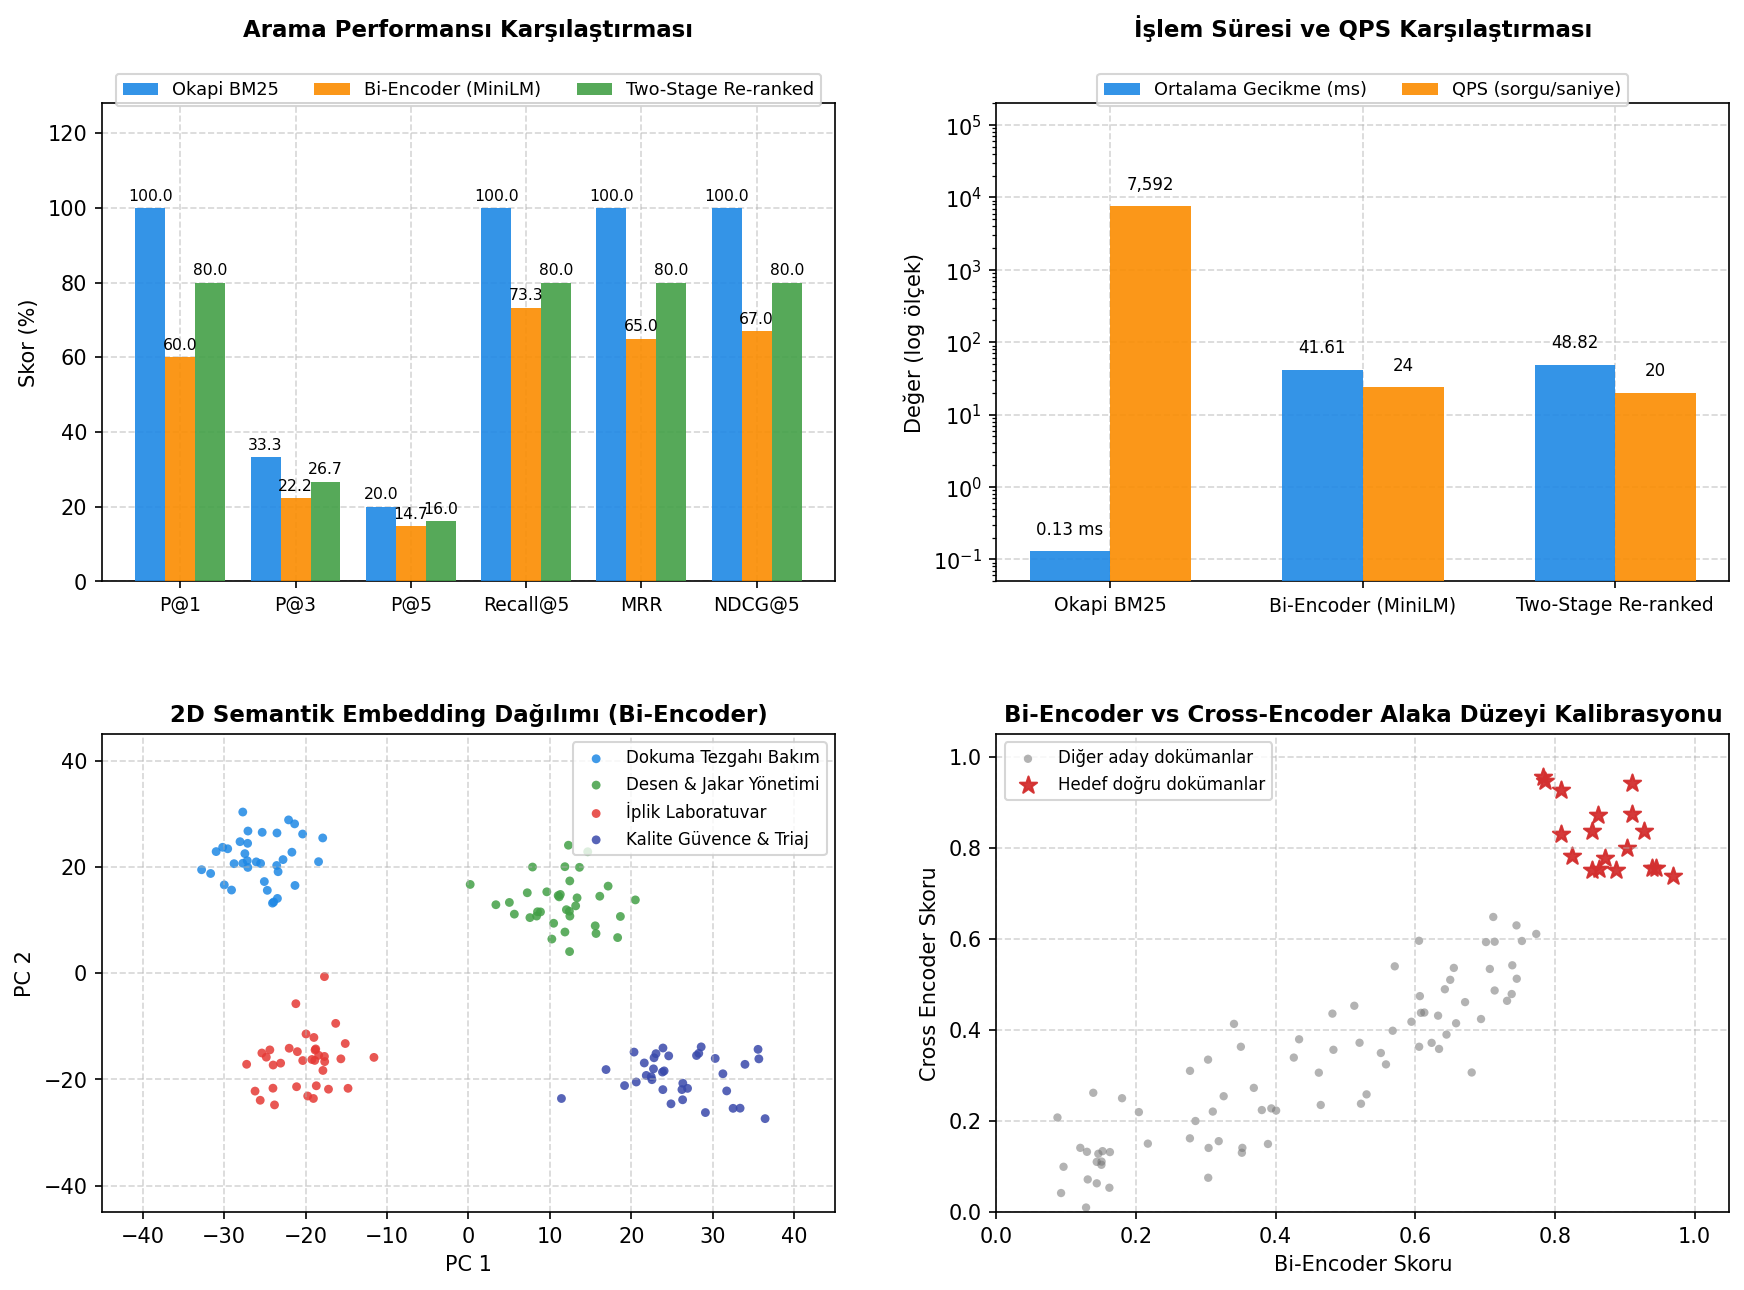

In [7]:
# 9. 2x2 Master Teşhis Panelinin Çizdirilmesi ve Görüntülenmesi
from IPython.display import Image as IPImage, display
from pathlib import Path

panel_path = Path('mini_project/outputs/dense_retrieval_panel.png')
if not panel_path.exists():
    panel_path = Path('day23/mini_project/outputs/dense_retrieval_panel.png')

if panel_path.exists():
    display(IPImage(filename=str(panel_path), width=1000))
else:
    print('Panel dosyası bulunamadı.')

### 10. Sonuç ve Faz 4 Devam Adımları

- **Cross-Encoder'ın Gücü:** Bi-Encoder tek başına %60.0 P@1 ve 0.6500 MRR elde ederken, Cross-Encoder ikinci aşamada tam çapraz dikkat uygulayarak skoru **%80.0 P@1 ve 0.8000 MRR** seviyesine taşımıştır.
- **Hız - Doğruluk Dengesi:** 52 dokümanda Bi-Encoder ortalama ~41 ms, Cross-Encoder ise yalnızca ~7 ms ek gecikme ekleyerek toplamda 48.82 ms içerisinde derin anlamsal getirme sağlamaktadır.
- **Sıradaki Gün (Day 24):** Hibrit Arama ve Karşılıklı Sıra Füzyonu (Hybrid Retrieval: BM25 + Dense Qdrant Fusion via Reciprocal Rank Fusion - RRF) ile hem leksikal hem de semantik modeller tek bir potada birleştirilecektir.